In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
Dataset = pd.read_csv('Hybrid_Energy_Site_Samples_PCS_30m.csv')  
Dataset.head()

,system:index,Dist_to_railway,Dist_to_road,Dist_to_tyranss,Elevation,GHI,LULC,River_Dist,Wind,.geo
0,0,39714.628906,8147.200195,32637.005859,411.0,5.760000,2.0,598.977051,5.250,"{""type"":""Point"",""coordinates"":[8.3577885899435..."
1,1,16242.950195,0.000000,156.889343,7.0,5.118325,11.0,0.000000,3.251,"{""type"":""Point"",""coordinates"":[3.1797109827120..."
2,2,92478.523438,0.000000,101954.906250,400.0,6.160000,11.0,3810.678467,6.002,"{""type"":""Point"",""coordinates"":[13.875265934311..."
3,3,161591.093750,1016.463501,129096.289062,272.0,6.050000,7.0,10123.613281,4.120,"{""type"":""Point"",""coordinates"":[9.9207774965204..."
4,4,63809.843750,3229.203613,28574.027344,365.0,6.180000,11.0,0.000000,6.925,"{""type"":""Point"",""coordinates"":[11.946928578230..."


In [3]:
import json

Dataset['lon'] = Dataset['.geo'].apply(lambda x: json.loads(x)['coordinates'][0])
Dataset['lat'] = Dataset['.geo'].apply(lambda x: json.loads(x)['coordinates'][1])

In [5]:
Dataset.head(15)

,system:index,Dist_to_railway,Dist_to_road,Dist_to_tyranss,Elevation,GHI,LULC,River_Dist,Wind,.geo,lon,lat
0,0,39714.628906,8147.200195,32637.005859,411.0,5.760000,2.0,598.977051,5.250,"{""type"":""Point"",""coordinates"":[8.3577885899435...",8.357789,6.764111
1,1,16242.950195,0.000000,156.889343,7.0,5.118325,11.0,0.000000,3.251,"{""type"":""Point"",""coordinates"":[3.1797109827120...",3.179711,6.500134
2,2,92478.523438,0.000000,101954.906250,400.0,6.160000,11.0,3810.678467,6.002,"{""type"":""Point"",""coordinates"":[13.875265934311...",13.875266,11.154675
3,3,161591.093750,1016.463501,129096.289062,272.0,6.050000,7.0,10123.613281,4.120,"{""type"":""Point"",""coordinates"":[9.9207774965204...",9.920777,7.201531
4,4,63809.843750,3229.203613,28574.027344,365.0,6.180000,11.0,0.000000,6.925,"{""type"":""Point"",""coordinates"":[11.946928578230...",11.946929,10.237687
5,5,127232.617188,23009.548828,84941.468750,283.0,5.870000,11.0,5094.516602,4.795,"{""type"":""Point"",""coordinates"":[3.8951952095627...",3.895195,9.864546
6,6,51910.468750,1832.957764,7225.152344,308.0,5.430000,2.0,1190.208008,4.131,"{""type"":""Point"",""coordinates"":[6.0264852097720...",6.026485,7.233499
7,7,111465.429688,93.337593,5246.698242,30.0,5.210000,2.0,7529.800293,2.365,"{""type"":""Point"",""coordinates"":[4.5650983344795...",4.565098,6.552150
8,8,65622.789062,3352.447510,15562.849609,253.0,6.000000,11.0,4263.551758,6.800,"{""type"":""Point"",""coordinates"":[5.8992980890670...",5.899298,10.378355
9,9,17250.515625,1261.800171,8555.581055,383.0,5.350000,7.0,15741.357422,4.350,"{""type"":""Point"",""coordinates"":[7.3841926479134...",7.384193,6.286871


In [4]:
train = Dataset[Dataset['lat'] >= 9]   # North
test  = Dataset[Dataset['lat'] < 9]    # South

In [5]:
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 18391
Test size: 11608


In [6]:
# Dropoing unwanted columns
Cleaned_train_Dataset = train.drop(columns=[".geo", "system:index", "lon", "lat"])
Cleaned_train_Dataset.head()

,Dist_to_railway,Dist_to_road,Dist_to_tyranss,Elevation,GHI,LULC,River_Dist,Wind
2,92478.523438,0.000000,101954.906250,400.0,6.16,11.0,3810.678467,6.002
4,63809.843750,3229.203613,28574.027344,365.0,6.18,11.0,0.000000,6.925
5,127232.617188,23009.548828,84941.468750,283.0,5.87,11.0,5094.516602,4.795
8,65622.789062,3352.447510,15562.849609,253.0,6.00,11.0,4263.551758,6.800
16,32101.861328,3501.831543,17189.886719,392.0,6.10,11.0,400.335175,6.576


In [7]:
# Dropoing unwanted columns
Cleaned_test_Dataset = test.drop(columns=[".geo", "system:index", "lon", "lat"])
Cleaned_test_Dataset.head()

,Dist_to_railway,Dist_to_road,Dist_to_tyranss,Elevation,GHI,LULC,River_Dist,Wind
0,39714.628906,8147.200195,32637.005859,411.0,5.760000,2.0,598.977051,5.250
1,16242.950195,0.000000,156.889343,7.0,5.118325,11.0,0.000000,3.251
3,161591.093750,1016.463501,129096.289062,272.0,6.050000,7.0,10123.613281,4.120
6,51910.468750,1832.957764,7225.152344,308.0,5.430000,2.0,1190.208008,4.131
7,111465.429688,93.337593,5246.698242,30.0,5.210000,2.0,7529.800293,2.365


In [8]:


# --- Classification Functions ---
Cleaned_train_Dataset = Cleaned_train_Dataset.copy()
import pandas as pd

# Load your data
df = Cleaned_train_Dataset

# Define scoring functions
def wind_score(w):
    if w >= 6.0: return 4
    elif 5.0 <= w < 6.0: return 3
    elif 4.0 <= w < 5.0: return 2
    else: return 1

def ghi_score(g):
    if g >= 5.75: return 4
    elif 4.93 <= g < 5.75: return 3
    elif 4.11 <= g < 4.93: return 2
    else: return 1

def lulc_score(l):
    if l in [2, 5, 11]: return 4  # Suitable
    elif l == 3: return 2        # Unsuitable (Forest)
    elif l in [0, 4]: return 1   # Not suitable
    else: return 1

def trans_line_score(d):
    if 250.1 <= d <= 5000: return 4
    elif 5001 <= d <= 10000: return 3
    elif 10001 <= d <= 20000: return 2
    else: return 1

def road_score(d):
    if 500 <= d <= 2500: return 4
    elif 2500 < d <= 5000: return 3
    elif 5000 < d <= 10000: return 2
    else: return 1

def rail_score(d):
    if d >= 280000:
        return 4  # Highly Suitable
    elif 200000 <= d < 280000:
        return 3  # Suitable
    elif 71000 <= d < 200000:
        return 2  # Marginally Suitable
    else:
        return 1  # Unsuitable

def elevation_score(e):
    if e < 250: return 4
    elif e < 500: return 3
    elif e < 1000: return 2
    else: return 1

def river_score(d):
    return 1 if 500 <= d <= 1000 else 0

# Apply scores
df["wind_score"] = df["Wind"].apply(wind_score)
df["ghi_score"] = df["GHI"].apply(ghi_score)
df["lulc_score"] = df["LULC"].apply(lulc_score)
df["trans_score"] = df["Dist_to_tyranss"].apply(trans_line_score)
df["road_score"] = df["Dist_to_road"].apply(road_score)
df["rail_score"] = df["Dist_to_railway"].apply(rail_score)
df["elev_score"] = df["Elevation"].apply(elevation_score)
df["hydrogen_zone"] = df["River_Dist"].apply(river_score)

# Weighted total score
df["total_score"] = (
    df["ghi_score"] * 0.25 +
    df["wind_score"] * 0.25 +
    df["lulc_score"] * 0.20 +
    df["trans_score"] * 0.10 +
    df["road_score"] * 0.10 +
    df["rail_score"] * 0.05 +
    df["elev_score"] * 0.05
)

# Mapping dictionary for later reference
suitability_mapping = {
    3: "Highly Suitable",
    2: "Suitable",
    1: "Marginally Suitable",
    0: "Unsuitable"
}

# Label suitability as numeric codes
def label_suitability(score):
    if score >= 3.4:
        return 3  # Highly Suitable
    elif score >= 2.9:
        return 2  # Suitable
    elif score >= 2.4:
        return 1  # Marginally Suitable
    else:
        return 0  # Unsuitable

df["Suitability"] = df["total_score"].apply(label_suitability)



In [9]:
Cleaned_train_Dataset.head(1000)

,Dist_to_railway,Dist_to_road,Dist_to_tyranss,Elevation,GHI,LULC,River_Dist,Wind,wind_score,ghi_score,lulc_score,trans_score,road_score,rail_score,elev_score,hydrogen_zone,total_score,Suitability
2,92478.523438,0.000000,101954.906250,400.0,6.16,11.0,3810.678467,6.002,4,4,4,1,1,2,3,0,3.25,2
4,63809.843750,3229.203613,28574.027344,365.0,6.18,11.0,0.000000,6.925,4,4,4,1,3,1,3,0,3.40,3
5,127232.617188,23009.548828,84941.468750,283.0,5.87,11.0,5094.516602,4.795,2,4,4,1,1,2,3,0,2.75,1
8,65622.789062,3352.447510,15562.849609,253.0,6.00,11.0,4263.551758,6.800,4,4,4,2,3,1,3,0,3.50,3
16,32101.861328,3501.831543,17189.886719,392.0,6.10,11.0,400.335175,6.576,4,4,4,2,3,1,3,0,3.50,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,73323.492188,5234.984375,61755.207031,425.0,6.11,5.0,8270.350586,7.115,4,4,4,1,2,2,3,0,3.35,2
1580,79676.265625,54.084549,15280.014648,601.0,6.18,11.0,0.000000,7.520,4,4,4,2,1,2,2,0,3.30,2
1581,89014.578125,4794.698730,78448.210938,361.0,6.16,2.0,8289.873047,6.002,4,4,4,1,3,2,3,0,3.45,3
1582,100060.460938,1138.047363,116613.632812,292.0,5.83,11.0,11689.805664,7.348,4,4,4,1,4,2,3,0,3.55,3


In [10]:

suitability_counts = df['Suitability'].value_counts()

# Display the counts
print("Suitability Class Counts:")
print(suitability_counts)



Suitability Class Counts:
Suitability
2    9016
3    7683
1    1532
0     160
Name: count, dtype: int64


In [11]:


# --- Classification Functions ---
Cleaned_test_Dataset = Cleaned_test_Dataset.copy()
import pandas as pd

# Load your data
df = Cleaned_test_Dataset

# Define scoring functions
def wind_score(w):
    if w >= 6.0: return 4
    elif 5.0 <= w < 6.0: return 3
    elif 4.0 <= w < 5.0: return 2
    else: return 1

def ghi_score(g):
    if g >= 5.75: return 4
    elif 4.93 <= g < 5.75: return 3
    elif 4.11 <= g < 4.93: return 2
    else: return 1

def lulc_score(l):
    if l in [2, 5, 11]: return 4  # Suitable
    elif l == 3: return 2        # Unsuitable (Forest)
    elif l in [0, 4]: return 1   # Not suitable
    else: return 1

def trans_line_score(d):
    if 250.1 <= d <= 5000: return 4
    elif 5001 <= d <= 10000: return 3
    elif 10001 <= d <= 20000: return 2
    else: return 1

def road_score(d):
    if 500 <= d <= 2500: return 4
    elif 2500 < d <= 5000: return 3
    elif 5000 < d <= 10000: return 2
    else: return 1

def rail_score(d):
    if d >= 280000:
        return 4  # Highly Suitable
    elif 200000 <= d < 280000:
        return 3  # Suitable
    elif 71000 <= d < 200000:
        return 2  # Marginally Suitable
    else:
        return 1  # Unsuitable

def elevation_score(e):
    if e < 250: return 4
    elif e < 500: return 3
    elif e < 1000: return 2
    else: return 1

def river_score(d):
    return 1 if 500 <= d <= 1000 else 0

# Apply scores
df["wind_score"] = df["Wind"].apply(wind_score)
df["ghi_score"] = df["GHI"].apply(ghi_score)
df["lulc_score"] = df["LULC"].apply(lulc_score)
df["trans_score"] = df["Dist_to_tyranss"].apply(trans_line_score)
df["road_score"] = df["Dist_to_road"].apply(road_score)
df["rail_score"] = df["Dist_to_railway"].apply(rail_score)
df["elev_score"] = df["Elevation"].apply(elevation_score)
df["hydrogen_zone"] = df["River_Dist"].apply(river_score)

# Weighted total score
df["total_score"] = (
    df["ghi_score"] * 0.25 +
    df["wind_score"] * 0.25 +
    df["lulc_score"] * 0.20 +
    df["trans_score"] * 0.10 +
    df["road_score"] * 0.10 +
    df["rail_score"] * 0.05 +
    df["elev_score"] * 0.05
)

# Mapping dictionary for later reference
suitability_mapping = {
    3: "Highly Suitable",
    2: "Suitable",
    1: "Marginally Suitable",
    0: "Unsuitable"
}

# Label suitability as numeric codes
def label_suitability(score):
    if score >= 3.4:
        return 3  # Highly Suitable
    elif score >= 2.9:
        return 2  # Suitable
    elif score >= 2.4:
        return 1  # Marginally Suitable
    else:
        return 0  # Unsuitable

df["Suitability"] = df["total_score"].apply(label_suitability)



In [12]:
Cleaned_test_Dataset.head(100)

,Dist_to_railway,Dist_to_road,Dist_to_tyranss,Elevation,GHI,LULC,River_Dist,Wind,wind_score,ghi_score,lulc_score,trans_score,road_score,rail_score,elev_score,hydrogen_zone,total_score,Suitability
0,39714.628906,8147.200195,32637.005859,411.0,5.760000,2.0,598.977051,5.250,3,4,4,1,2,1,3,1,3.05,2
1,16242.950195,0.000000,156.889343,7.0,5.118325,11.0,0.000000,3.251,1,3,4,1,1,1,4,0,2.25,0
3,161591.093750,1016.463501,129096.289062,272.0,6.050000,7.0,10123.613281,4.120,2,4,1,1,4,2,3,0,2.45,1
6,51910.468750,1832.957764,7225.152344,308.0,5.430000,2.0,1190.208008,4.131,2,3,4,3,4,1,3,0,2.95,2
7,111465.429688,93.337593,5246.698242,30.0,5.210000,2.0,7529.800293,2.365,1,3,4,3,1,2,4,0,2.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,2010.454468,2668.877686,3661.353760,132.0,6.089478,11.0,0.000000,6.515,4,4,4,4,3,1,4,0,3.75,3
259,20569.644531,0.000000,36687.148438,372.0,5.570000,11.0,6652.383789,3.781,1,3,4,1,1,1,3,0,2.20,0
261,118794.101562,10433.508789,79327.609375,324.0,5.540000,11.0,22359.283203,4.069,2,3,4,1,1,2,3,0,2.50,1
262,112266.046875,414.750916,71441.843750,77.0,5.930000,2.0,4263.551758,3.335,1,4,4,1,1,2,4,0,2.55,1


In [13]:
suitability_counts = df['Suitability'].value_counts()

# Display the counts
print("Suitability Class Counts:")
print(suitability_counts)

Suitability Class Counts:
Suitability
1    5258
0    2845
2    2709
3     796
Name: count, dtype: int64


In [14]:
features = ['GHI', 'Dist_to_railway', 'Dist_to_road', 'Dist_to_tyranss', 'Elevation', 'LULC', 'Wind']
X_train = Cleaned_train_Dataset[features]
y_train = Cleaned_train_Dataset['Suitability']

X_test = Cleaned_test_Dataset[features]
y_test = Cleaned_test_Dataset['Suitability']

In [15]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = forest.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7566333563059958


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1220 1622    3    0]
 [ 492 4458  308    0]
 [   5  263 2396   45]
 [   0    1  132  663]]


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.46      0.56      2845
           1       0.71      0.84      0.77      5258
           2       0.84      0.89      0.86      2709
           3       0.94      0.83      0.88       796

    accuracy                           0.76     11608
   macro avg       0.80      0.76      0.77     11608
weighted avg       0.76      0.76      0.75     11608



In [18]:
from sklearn.metrics import roc_auc_score

y_prob = forest.predict_proba(X_test)

auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("ROC-AUC:", auc)

ROC-AUC: 0.9305100102256059


In [19]:
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2, 3]
y_test_bin = label_binarize(y_test, classes=classes)

In [20]:
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2, 3]
y_test_bin = label_binarize(y_test, classes=classes)

In [21]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

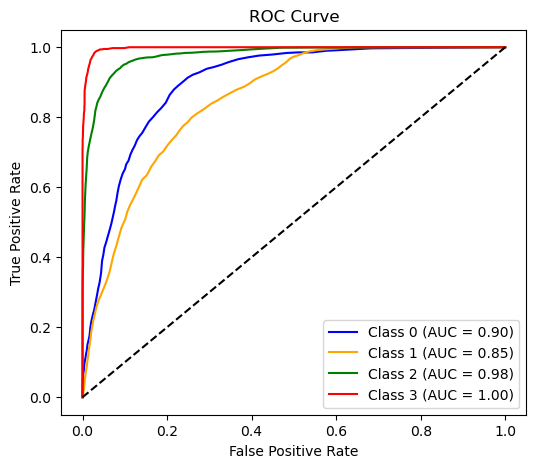

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

colors = ['blue', 'orange', 'green', 'red']

for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Diagonal line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(forest, X_train, y_train, cv=5)

print("K-fold scores:", scores)
print("Mean accuracy:", scores.mean())

K-fold scores: [0.96711063 0.97335508 0.97362697 0.96900489 0.97036433]
Mean accuracy: 0.9706923811512839


In [24]:
from sklearn.metrics import accuracy_score

agreement = accuracy_score(y_test, y_pred)
print("Agreement with MCDM:", agreement)

Agreement with MCDM: 0.7566333563059958


In [31]:
import joblib

# Save the model
joblib.dump(forest, "suitability_model_spatial.pkl")

['suitability_model_spatial.pkl']

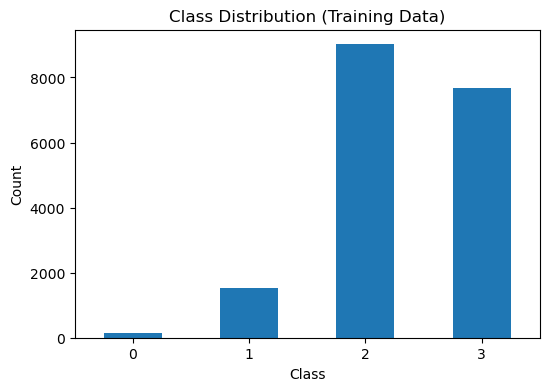

In [25]:
import matplotlib.pyplot as plt

# Count class distribution
class_counts = y_train.value_counts().sort_index()

# Plot
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')

plt.title("Class Distribution (Training Data)")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.show()

In [26]:
n_trees = [10, 50, 100, 200, 300]
accuracies = []

In [27]:
for n in n_trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42, class_weight='balanced')
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

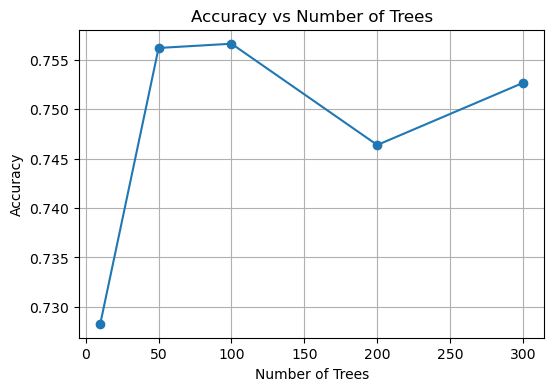

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(n_trees, accuracies, marker='o')

plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

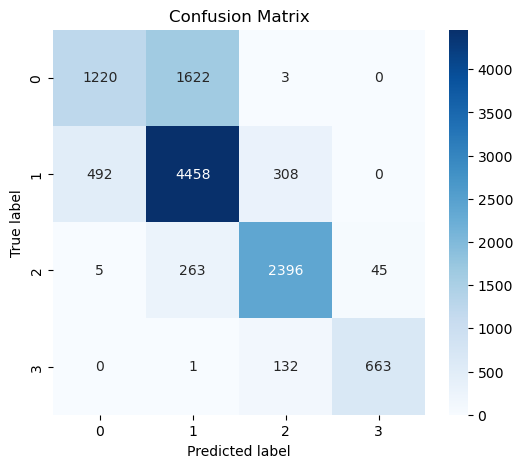

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm, 
            annot=True,        # show numbers
            fmt='d',           # integer format
            cmap='Blues')      # color style

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.show()